In [ ]:
print("Hello Oil Spill Detection")

Hello Oil Spill Detection


In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
import os

project_name = "Oil_Spill_Detection"

os.makedirs(project_name, exist_ok=True)

print("Folder created:", project_name)

Folder created: Oil_Spill_Detection


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/MyDrive/Oil_Spill_Detection"

folders = [
    "Dataset",
    "Models",
    "Results",
    "Test_Images"
]

for folder in folders:
    os.makedirs(os.path.join(project_path, folder), exist_ok=True)

print("Project structure created successfully!")

Project structure created successfully!


In [ ]:
import os

path = "/content/drive/MyDrive/Oil_Spill_Detection/Dataset"

os.listdir(path)

['archive.zip']

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Oil_Spill_Detection/Dataset/archive.zip"

extract_path = "/content/drive/MyDrive/Oil_Spill_Detection/Dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [ ]:
os.listdir("/content/drive/MyDrive/Oil_Spill_Detection/Dataset")

['archive.zip', 'kaggle']

In [ ]:
import os

data_path = "/content/drive/MyDrive/Oil_Spill_Detection/Dataset/kaggle/data"

print("Folders:", os.listdir(data_path))

print("Class 0 images:", len(os.listdir(data_path + "/Class_0")))
print("Class 1 images:", len(os.listdir(data_path + "/Class_1")))

Folders: ['Class_0', 'Class_1', 'sample']
Class 0 images: 3695
Class 1 images: 1843


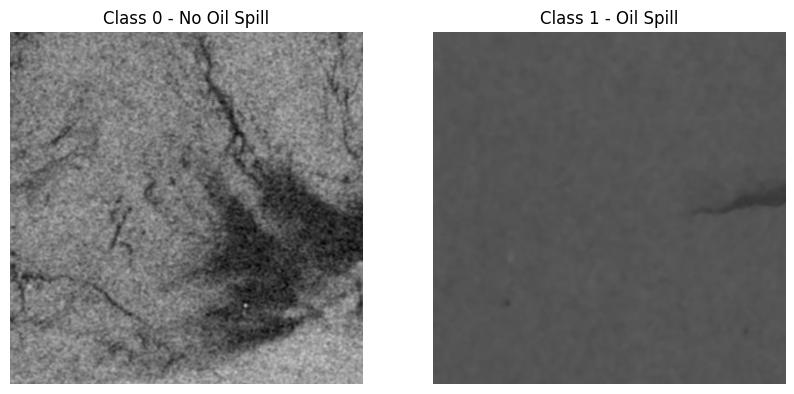

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

data_path = "/content/drive/MyDrive/Oil_Spill_Detection/Dataset/kaggle/data"

# Pick one image from Class_0
no_spill_img = os.listdir(data_path + "/Class_0")[0]

# Pick one image from Class_1
spill_img = os.listdir(data_path + "/Class_1")[0]

img1 = mpimg.imread(data_path + "/Class_0/" + no_spill_img)
img2 = mpimg.imread(data_path + "/Class_1/" + spill_img)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img1)
plt.title("Class 0 - No Oil Spill")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title("Class 1 - Oil Spill")
plt.axis("off")

plt.show()

In [ ]:
from PIL import Image
import os

data_path = "/content/drive/MyDrive/Oil_Spill_Detection/Dataset/kaggle/data"

img_path = os.path.join(data_path, "Class_1", os.listdir(data_path + "/Class_1")[0])

img = Image.open(img_path)

print("Image size:", img.size)
print("Image mode:", img.mode)

Image size: (400, 400)
Image mode: RGB


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

dataset_path = "/content/drive/MyDrive/Oil_Spill_Detection/Dataset/kaggle/data"

img_size = (224, 224)
batch_size = 32

dataset = image_dataset_from_directory(
    dataset_path,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42
)

class_names = dataset.class_names

print(class_names)

Found 5548 files belonging to 3 classes.
['Class_0', 'Class_1', 'sample']


In [ ]:
import os
import shutil

source = "/content/drive/MyDrive/Oil_Spill_Detection/Dataset/kaggle/data"

destination = "/content/drive/MyDrive/Oil_Spill_Detection/Dataset/clean_data"

os.makedirs(destination, exist_ok=True)

for folder in ["Class_0", "Class_1"]:
    shutil.copytree(
        os.path.join(source, folder),
        os.path.join(destination, folder),
        dirs_exist_ok=True
    )

print("Clean dataset created!")

Clean dataset created!


In [ ]:
dataset_path = "/content/drive/MyDrive/Oil_Spill_Detection/Dataset/clean_data"

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

dataset_path = "/content/drive/MyDrive/Oil_Spill_Detection/Dataset/clean_data"

img_size = (224, 224)
batch_size = 32

dataset = image_dataset_from_directory(
    dataset_path,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42
)

class_names = dataset.class_names

print(class_names)

Found 5538 files belonging to 2 classes.
['Class_0', 'Class_1']


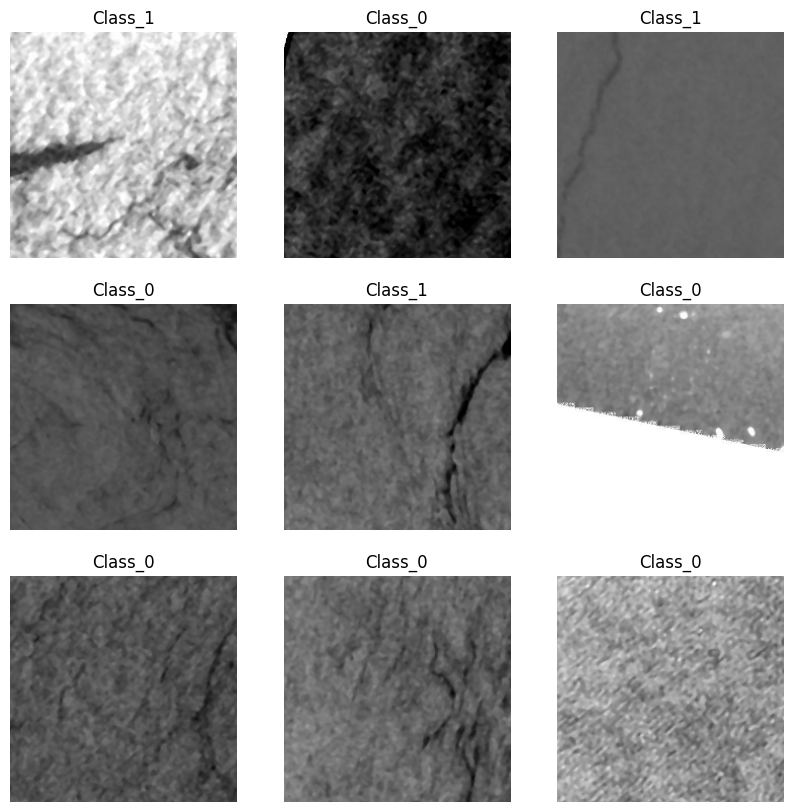

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [ ]:
import tensorflow as tf

total_batches = len(dataset)

train_size = int(0.7 * total_batches)
val_size = int(0.2 * total_batches)

train_ds = dataset.take(train_size)

remaining = dataset.skip(train_size)

val_ds = remaining.take(val_size)

test_ds = remaining.skip(val_size)

print("Training batches:", len(train_ds))
print("Validation batches:", len(val_ds))
print("Testing batches:", len(test_ds))

Training batches: 121
Validation batches: 34
Testing batches: 19


In [ ]:
# Normalization function
def normalize(image, label):
    image = image / 255.0
    return image, label


# Apply normalization
train_ds = train_ds.map(normalize)
val_ds = val_ds.map(normalize)
test_ds = test_ds.map(normalize)


# Check values
for image, label in train_ds.take(1):
    print("Image shape:", image.shape)
    print("Pixel range:", image.numpy().min(), "to", image.numpy().max())
    print("Label:", label.numpy())

Image shape: (32, 224, 224, 3)
Pixel range: 0.0 to 1.0
Label: [0 1 1 1 0 1 0 1 1 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0]


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models


model = models.Sequential([

    # Input layer
    layers.Input(shape=(224,224,3)),

    # Feature extraction
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Convert features into 1D
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(1, activation='sigmoid')
])


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomContrast

In [ ]:
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
    RandomZoom(0.2),
    RandomContrast(0.2)
])

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

In [ ]:
base_model = MobileNetV2(
    input_shape=(400,400,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

/tmp/ipykernel_2532/2042597004.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
inputs = tf.keras.Input(shape=(400,400,3))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation="relu")(x)

x = Dropout(0.5)(x)

outputs = Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 400, 400, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 400, 400, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 13, 13, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
import numpy as np
from sklearn.utils import class_weight

# Get labels from training dataset
train_labels = []

for images, labels in train_ds:
    train_labels.extend(labels.numpy())

train_labels = np.array(train_labels)

# Calculate class weights
weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(enumerate(weights))

class_weights

{0: np.float64(0.7503875968992249), 1: np.float64(1.498452012383901)}

In [ ]:
del model

In [ ]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

In [ ]:
del data_augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
    RandomZoom(0.2),
    RandomContrast(0.2)
], name="data_augmentation")

In [ ]:
inputs = tf.keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation="relu")(x)

x = Dropout(0.5)(x)

outputs = Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights
)

Epoch 1/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 301s 2s/step - accuracy: 0.7534 - loss: 0.5196 - val_accuracy: 0.8208 - val_loss: 0.3847
Epoch 2/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 316s 2s/step - accuracy: 0.8530 - loss: 0.3635 - val_accuracy: 0.9182 - val_loss: 0.2594
Epoch 3/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 272s 2s/step - accuracy: 0.8742 - loss: 0.3247 - val_accuracy: 0.8888 - val_loss: 0.2981
Epoch 4/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 339s 2s/step - accuracy: 0.8825 - loss: 0.3106 - val_accuracy: 0.8805 - val_loss: 0.3071
Epoch 5/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.8910 - loss: 0.2862 - val_accuracy: 0.9145 - val_loss: 0.2400
Epoch 6/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 291s 2s/step - accuracy: 0.8908 - loss: 0.2912 - val_accuracy: 0.9173 - val_loss: 0.2285
Epoch 7/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 274s 2s/step - accuracy: 0.8951 - loss: 0.2750 - val_accuracy: 0.8787 - val_loss: 0.3016
Epoch 8/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.8962 - loss: 0.2663 - val_accu

In [ ]:
model.evaluate(test_ds)

19/19 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.9308 - loss: 0.1998


[0.1998126208782196, 0.9307958483695984]

In [ ]:
model.save("oil_spill_mobilenetv2.keras")

In [ ]:
import os

print(os.listdir())

['.config', 'drive', 'Oil_Spill_Detection', 'oil_spill_mobilenetv2.keras', 'sample_data']


In [ ]:
model.save("/content/drive/MyDrive/Oil_Spill_Detection/Models/oil_spill_mobilenetv2.keras")

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving class_1_00006.jpg to class_1_00006.jpg


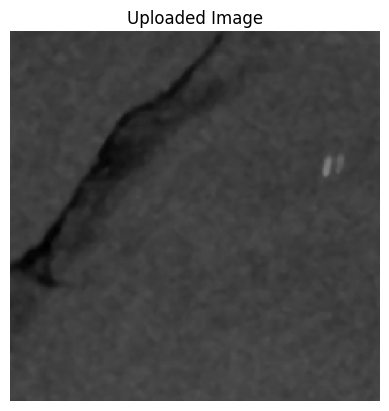

In [ ]:
img_path = "class_1_00006.jpg"

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

plt.imshow(img)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

In [ ]:
prediction = model.predict(img_array)

print("Raw Prediction:", prediction)

if prediction[0][0] > 0.5:
    print("Prediction: Oil Spill")
    print(f"Confidence: {prediction[0][0] * 100:.2f}%")
else:
    print("Prediction: No Oil Spill")
    print(f"Confidence: {(1 - prediction[0][0]) * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Raw Prediction: [[0.9937703]]
Prediction: Oil Spill
Confidence: 99.38%


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving class_0_00010.jpg to class_0_00010.jpg


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving class_0_00010.jpg to class_0_00010 (1).jpg


In [ ]:
img_path = "class_0_00012.jpg"

In [ ]:
print(uploaded.keys())

dict_keys(['class_0_00010 (1).jpg'])


In [ ]:
img_path = "class_0_00010 (1).jpg"

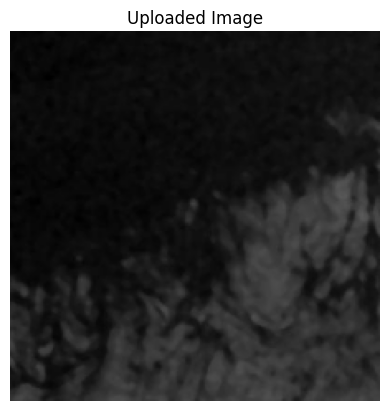

In [ ]:
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

plt.imshow(img)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

In [ ]:
prediction = model.predict(img_array)

print("Raw Prediction:", prediction)

if prediction[0][0] > 0.5:
    print("Prediction: Oil Spill")
    print(f"Confidence: {prediction[0][0] * 100:.2f}%")
else:
    print("Prediction: No Oil Spill")
    print(f"Confidence: {(1 - prediction[0][0]) * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Raw Prediction: [[0.01715924]]
Prediction: No Oil Spill
Confidence: 98.28%


In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'history' is not defined

<Figure size 800x500 with 0 Axes>

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/Oil_Spill_Detection/Models/oil_spill_mobilenetv2.keras")

In [ ]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,750,277 (10.49 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 328,196 (1.25 MB)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights
)

NameError: name 'train_ds' is not defined

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(...)
val_ds = ...
test_ds = ...

TypeError: listdir: path should be string, bytes, os.PathLike, integer or None, not ellipsis

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/Oil_Spill_Detection/Models/oil_spill_mobilenetv2.keras")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving class_1_00006.jpg to class_1_00006.jpg


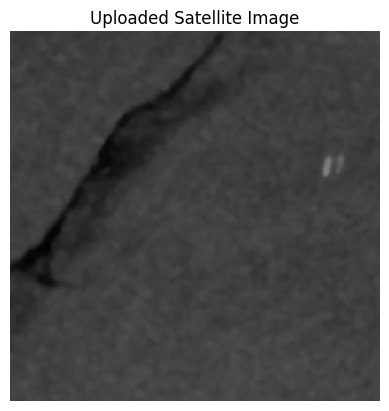

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Get uploaded filename
img_path = list(uploaded.keys())[0]

# Load and preprocess
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Display image
plt.imshow(img)
plt.title("Uploaded Satellite Image")
plt.axis("off")
plt.show()

In [ ]:
prediction = model.predict(img_array)

score = prediction[0][0]

print(f"Raw Prediction: {score:.6f}")

if score > 0.5:
    print("🛢️ Prediction: Oil Spill")
    print(f"Confidence: {score * 100:.2f}%")
else:
    print("🌊 Prediction: No Oil Spill")
    print(f"Confidence: {(1 - score) * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Raw Prediction: 0.993770
🛢️ Prediction: Oil Spill
Confidence: 99.38%


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving class_0_00010.jpg to class_0_00010.jpg


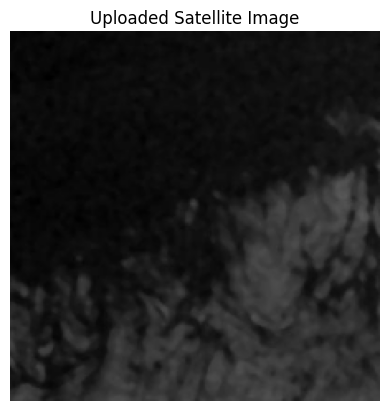

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Get uploaded filename
img_path = list(uploaded.keys())[0]

# Load and preprocess
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Display image
plt.imshow(img)
plt.title("Uploaded Satellite Image")
plt.axis("off")
plt.show()

In [ ]:
prediction = model.predict(img_array)

score = prediction[0][0]

print(f"Raw Prediction: {score:.6f}")

if score > 0.5:
    print("🛢️ Prediction: Oil Spill")
    print(f"Confidence: {score * 100:.2f}%")
else:
    print("🌊 Prediction: No Oil Spill")
    print(f"Confidence: {(1 - score) * 100:.2f}%")

NameError: name 'model' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/Oil_Spill_Detection/Models/oil_spill_mobilenetv2.keras")
print("✅ Model Loaded Successfully")

✅ Model Loaded Successfully


In [ ]:
prediction = model.predict(img_array)

score = prediction[0][0]

print(f"Raw Prediction: {score:.6f}")

if score > 0.5:
    print("Prediction: Oil Spill")
    print(f"Confidence: {score*100:.2f}%")
else:
    print("Prediction: No Oil Spill")
    print(f"Confidence: {(1-score)*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Raw Prediction: 0.017159
Prediction: No Oil Spill
Confidence: 98.28%
